In [63]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

In [3]:
df = pd.read_csv('creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [9]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [19]:
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
238800,-0.157339,0.765246,-0.707812,1.496885,-1.225252,-0.580504,0.703235,-0.201346,0.437036,0.502898,...,-0.027812,-0.180086,-0.568096,0.258503,-0.003892,-1.305472,0.058637,0.167858,0.325920,0
49383,-0.279746,-0.477661,-0.465695,1.005618,1.671863,-0.100929,-0.119410,-0.689786,0.603803,0.070024,...,0.095359,-0.164260,-0.448074,-0.011477,0.515203,-0.253552,0.041290,0.261906,0.112635,0
106806,0.195626,-0.171031,1.476273,-1.138152,0.351006,-1.637414,-1.263370,-0.088163,-1.173559,0.024991,...,-0.242511,-0.361128,-0.775653,0.041038,-0.581630,0.206215,-0.376348,0.033289,0.014763,0
155870,1.089779,0.258015,-5.286190,3.667154,-2.607427,-1.265373,-0.547849,-0.549874,1.639987,-0.287922,...,1.873310,-0.838327,1.071441,-0.226523,-0.543264,-0.026528,-0.494443,-0.482533,-1.287473,0
27514,-0.127157,-0.588717,1.339883,-0.194022,-1.401598,-1.072394,2.027893,3.071703,-0.471459,0.720831,...,0.067685,-0.074482,-0.355402,-0.077989,1.079025,0.545868,1.053271,-0.089793,-0.005801,0


In [48]:
X = df.drop('Class', axis=1)
y = df['Class']
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [21]:
original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
original_Xtrain.shape, original_Xtest.shape, original_ytrain.shape, original_ytest.shape

((227845, 30), (56962, 30), (227845,), (56962,))

In [23]:

count_train = original_ytrain.value_counts()[1]
count_test = original_ytest.value_counts()[1]
count_train, count_test
z_stat, p = proportions_ztest(count=[count_train, count_test], nobs=[original_ytrain.shape[0], original_ytest.shape[0]])
print('z-stat = {:5.3f}, p = {:5.3f}'.format(z_stat, p))

z-stat = 1.850, p = 0.064


In [24]:

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

In [25]:
df = df.sample(frac=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]
combined_df = pd.concat([fraud_df, non_fraud_df])
new_df = combined_df.sample(frac=1, random_state=42)

In [26]:
new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
252889,5.111437,0.837874,1.312902,-1.461469,-1.625229,0.427183,-0.326353,-0.355500,0.468876,-0.249522,...,0.567367,0.058207,-0.469613,-0.095726,0.637173,-0.182637,-0.152841,-0.098387,0.016155,0
124036,1.495144,-0.088558,-0.715414,0.608590,1.155501,-0.267565,-0.563748,-0.618898,0.698308,0.069837,...,-0.186978,0.130749,0.239389,-0.090227,0.411572,-0.216126,0.353896,-0.062361,0.008433,1
22823,0.799273,-0.613788,0.984164,-0.468173,1.259152,0.861266,-1.177010,-0.020796,-0.632414,0.186001,...,-0.013223,-0.007753,0.029621,0.047882,0.450178,0.079491,0.425086,0.010519,0.037183,0
156990,2.293440,0.289078,-1.000611,3.346850,-5.534491,6.835802,-0.299803,0.095951,-2.440419,1.286301,...,1.189814,0.439757,-0.694099,0.299660,-0.657601,0.101648,0.430457,0.824685,0.326952,1
281674,0.286872,1.006309,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,...,-0.017652,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,1


<Axes: >

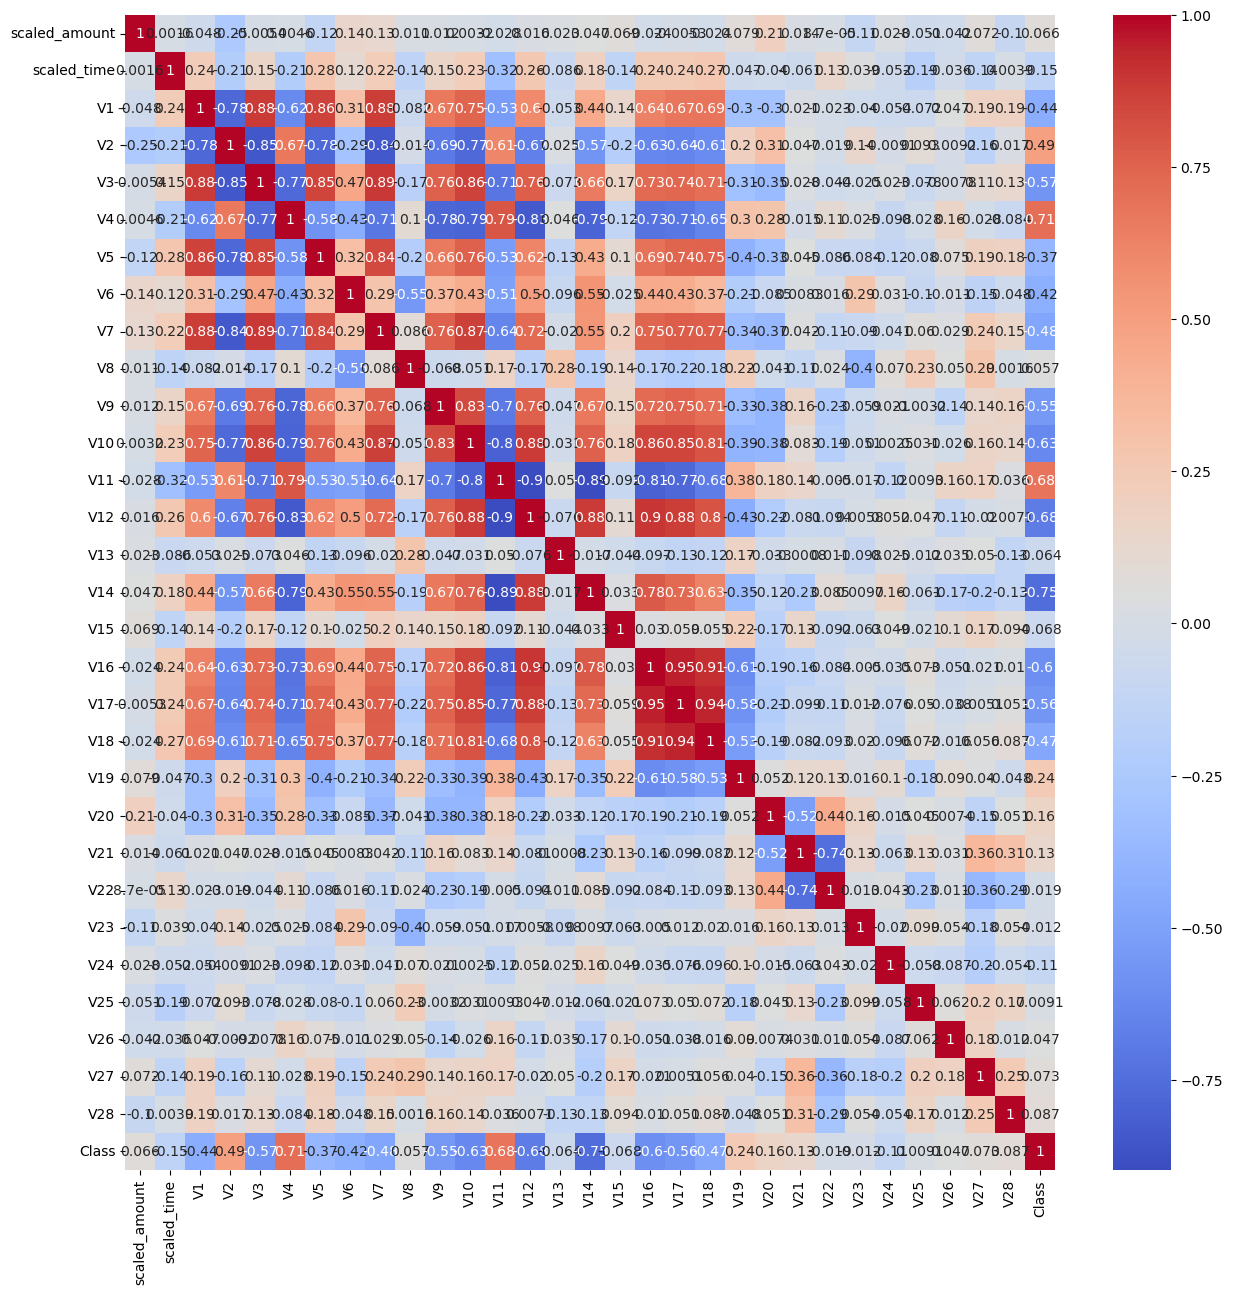

In [49]:
plt.figure(figsize=(15,15))
sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm',xticklabels=1, yticklabels=1,annot=True)

**Modeling & Evaluation**

In [27]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']
print(y)

252889    0
124036    1
22823     0
156990    1
281674    1
         ..
10630     1
42856     1
112298    0
12261     1
86155     1
Name: Class, Length: 984, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((787, 30), (197, 30), (787,), (197,))

In [30]:
X_train =X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

**LOGISTIC REGRESSION**

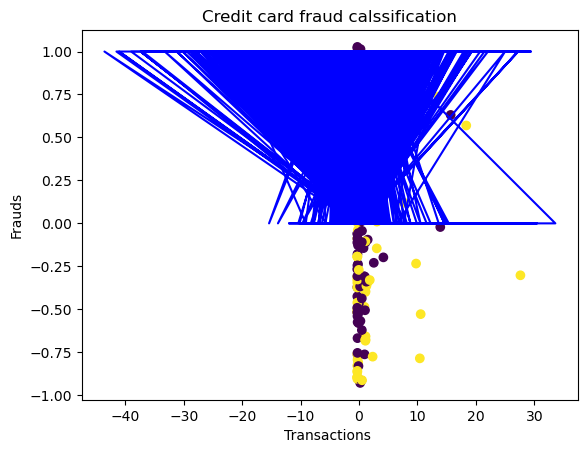

Logistic Regression has a trainning accuracy score of 94.0 %


In [31]:
# Logistic Regression
LR = LogisticRegression().fit(X_train, y_train)
y_pred=LR.predict(X_test)
x_pred=LR.predict(X_train)
plt.scatter(X_test[:, 0], X_test[:,1], c=y_pred)
plt.plot(X_train,x_pred,color="blue")
plt.xlabel('Transactions ')
plt.ylabel('Frauds')
plt.title('Credit card fraud calssification')
plt.show()
trainning_score_LR = cross_val_score(LR, X_train, y_train, cv=5)
print("Logistic Regression has a trainning accuracy score of", round(trainning_score_LR.mean(), 2) * 100, "%")

In [32]:
# Logistic Regression fine-tuning
LR_param = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_LR = GridSearchCV(LogisticRegression(), LR_param)
grid_LR.fit(X_train, y_train)
LR_fineTuned = grid_LR.best_estimator_


In [33]:
# Logistic Regression Prediction
LR_prediction = LR_fineTuned.predict(original_Xtest)
print(classification_report(original_ytest,LR_prediction))
print(confusion_matrix(original_ytest,LR_prediction))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56880
           1       0.04      0.96      0.07        82

    accuracy                           0.97     56962
   macro avg       0.52      0.96      0.53     56962
weighted avg       1.00      0.97      0.98     56962

[[54927  1953]
 [    3    79]]


**KNN**

  File "c:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


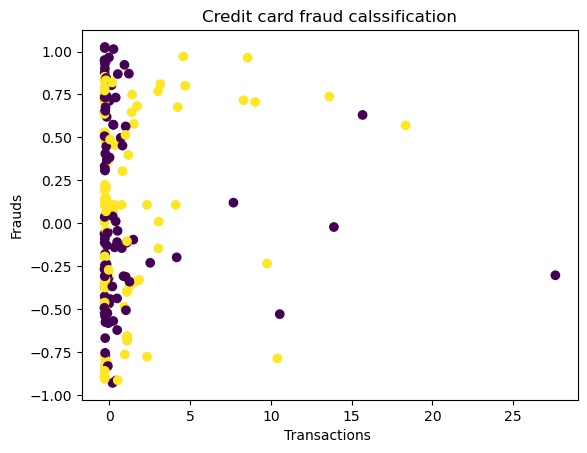

Knn has a training accuracy score of 93.0 %


In [34]:
# Knn
knn = KNeighborsClassifier().fit(X_train, y_train)
y_pred=knn.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:,1], c=y_pred)
plt.xlabel('Transactions ')
plt.ylabel('Frauds')
plt.title('Credit card fraud calssification')
plt.show()
training_score_knn = cross_val_score(knn, X_train, y_train, cv=5)

print("Knn has a training accuracy score of", round(training_score_knn.mean(),2) * 100, "%")

**SVM**

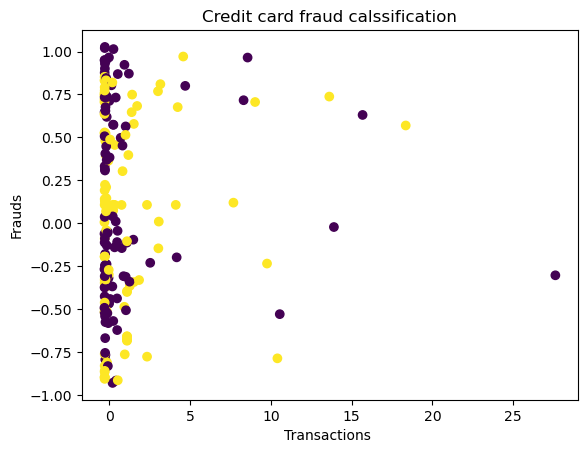

SVM has a training accuracy score of 93.0 %


In [35]:

# SVM
SVM = SVC().fit(X_train, y_train)
y_pred=SVM.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.xlabel('Transactions ')
plt.ylabel('Frauds')
plt.title('Credit card fraud calssification')
plt.show()
training_score_svc = cross_val_score(SVM, X_train, y_train, cv=5)
print("SVM has a training accuracy score of", round(training_score_svc.mean(),2) * 100, "%")

**DECISION TREE**

[Text(0.3826530612244898, 0.9642857142857143, 'x[15] <= -1.803\ngini = 0.5\nsamples = 787\nvalue = [405, 382]'), Text(0.14965986394557823, 0.8928571428571429, 'x[4] <= 0.109\ngini = 0.035\nsamples = 340\nvalue = [6, 334]'), Text(0.266156462585034, 0.9285714285714286, 'True  '), Text(0.12244897959183673, 0.8214285714285714, 'x[25] <= -1.66\ngini = 0.023\nsamples = 338\nvalue = [4, 334]'), Text(0.05442176870748299, 0.75, 'x[5] <= 1.371\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'), Text(0.027210884353741496, 0.6785714285714286, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'), Text(0.08163265306122448, 0.6785714285714286, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'), Text(0.19047619047619047, 0.75, 'x[2] <= 1.973\ngini = 0.012\nsamples = 335\nvalue = [2, 333]'), Text(0.1360544217687075, 0.6785714285714286, 'x[1] <= -0.916\ngini = 0.006\nsamples = 333\nvalue = [1, 332]'), Text(0.10884353741496598, 0.6071428571428571, 'x[11] <= -2.314\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'), Text(0.0816326530612

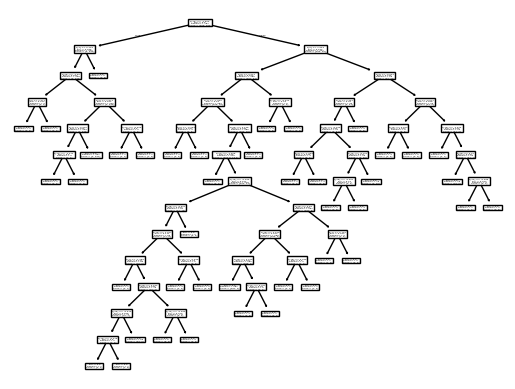

In [36]:
# DecisionTree
DT = DecisionTreeClassifier().fit(X_train, y_train)
y_pred=DT.predict(X_test)
from sklearn import tree
f=tree.plot_tree(DT)
print(f)
training_score_DT = cross_val_score(DT, X_train, y_train, cv=5)
print("DecisionTree has a training accuracy score of", round(training_score_DT.mean(),2) * 100, "%")

In [37]:
# DecisionTree fine-tuning
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)
DT_fineTuned = grid_tree.best_estimator_

In [38]:
# DecisionTree Prediction
DT_prediction = DT_fineTuned.predict(original_Xtest)
print(classification_report(original_ytest, DT_prediction))
print(confusion_matrix(original_ytest,DT_prediction))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56880
           1       0.05      0.89      0.09        82

    accuracy                           0.97     56962
   macro avg       0.52      0.93      0.54     56962
weighted avg       1.00      0.97      0.99     56962

[[55433  1447]
 [    9    73]]


**RANDOM FOREST**

In [39]:
# Random Forest
RF = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
predictions=RF.predict(X_test)
print(predictions)
print(len(predictions))
training_score_RF = cross_val_score(RF, X_train,y_train, cv=5)
print("RandomForest has a training accuracy score of", round(training_score_RF.mean(),2) * 100, "%")

[1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0
 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1
 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1
 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1
 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0
 0 1 1 1 0 0 0 0 1 1 0 1]
197
RandomForest has a training accuracy score of 93.0 %


**Naive bayes**

In [40]:
from sklearn.naive_bayes import GaussianNB


# instantiate the model
gnb = GaussianNB()


# fit the model
gnb.fit(X_train, y_train)

GaussianNB()

In [41]:
y_pred = gnb.predict(X_test)

y_pred

array([1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1])

In [42]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.8883


In [61]:
## xgboost
xgb = XGBClassifier().fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.89      0.97      0.93        87
           1       0.97      0.91      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197

[[ 84   3]
 [ 10 100]]


In [64]:
# gradient boosting
gb = GradientBoostingClassifier().fit(X_train, y_train)
y_pred = gb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        87
           1       0.99      0.92      0.95       110

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



In [43]:
!pip install gradio

In [44]:
def classify(num):
  if num<=0:
    return 'The transaction is Fair'
  elif num<=1:
    return 'The transaction is Fraud'

In [45]:
import gradio as gr
def predict_fraud(V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class):
  input_array=np.array([[V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class]])
  pred=RF.predict(input_array)
  output=classify(pred[0])
  if output=='The transaction is Fair':
    return[(0,output)]
  elif output=='The transaction is Fraud':
    return[(1,output)]

In [46]:
import pickle

# Save model
pickle.dump(RF, open("model.pkl", "wb"))

# Load model
model = pickle.load(open("model.pkl", "rb"))